# Sentiment Analysis — Fine-tuning

**Task:** 3-class sentiment classification → `positive` | `neutral` | `negative`  
**Model:** `bertweet-base`

**Dataset:** 27,482 train tweets · 3,535 test tweets  


In [ ]:
!pip install transformers datasets accelerate torch torchvision numpy pandas matplotlib scikit-learn seaborn tqdm

## Step 1 — Imports & Reproducibility

In [ ]:
import os, re, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_cosine_schedule_with_warmup,
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## Step 2 — Load Data

In [ ]:
# ── Label Config ─────────────────────────────────────────────────────────────
LABEL_MAP     = {'negative': 0, 'neutral': 1, 'positive': 2}
REV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}
CLASS_NAMES   = ['negative', 'neutral', 'positive']
CLASS_COLORS  = ['#e74c3c', '#3498db', '#2ecc71']
NUM_LABELS    = 3

# ── Data Loading ─────────────────────────────────────────────────────────────
TRAIN_PATH = 'train.csv'
TEST_PATH  = 'test.csv'

train_df = pd.read_csv(TRAIN_PATH, encoding='latin1')
test_df  = pd.read_csv(TEST_PATH,  encoding='latin1')

print(f'Train shape : {train_df.shape}')
print(f'Test  shape : {test_df.shape}')
print(f'\nTrain columns: {list(train_df.columns)}')
print(f'Test  columns: {list(test_df.columns)}')
print()
print(train_df.head(3))

Train shape : (27481, 10)
Test  shape : (4815, 9)

Train columns: ['textID', 'text', 'selected_text', 'sentiment', 'Time of Tweet', 'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)', 'Density (P/Km²)']
Test  columns: ['textID', 'text', 'sentiment', 'Time of Tweet', 'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)', 'Density (P/Km²)']

       textID                                            text  \
0  cb774db0d1             I`d have responded, if I were going   
1  549e992a42   Sooo SAD I will miss you here in San Diego!!!   
2  088c60f138                       my boss is bullying me...   

                         selected_text sentiment Time of Tweet Age of User  \
0  I`d have responded, if I were going   neutral       morning        0-20   
1                             Sooo SAD  negative          noon       21-30   
2                          bullying me  negative         night       31-45   

       Country  Population -2020  Land Area (Km²)  Density (P

## Step 3 — Exploratory Data Analysis (EDA)

=== Missing Values ===
textID              0
text                1
selected_text       1
sentiment           0
Time of Tweet       0
Age of User         0
Country             0
Population -2020    0
Land Area (Km²)     0
Density (P/Km²)     0
dtype: int64

Class distribution (train):
sentiment
neutral     11118
positive     8582
negative     7781
Name: count, dtype: int64


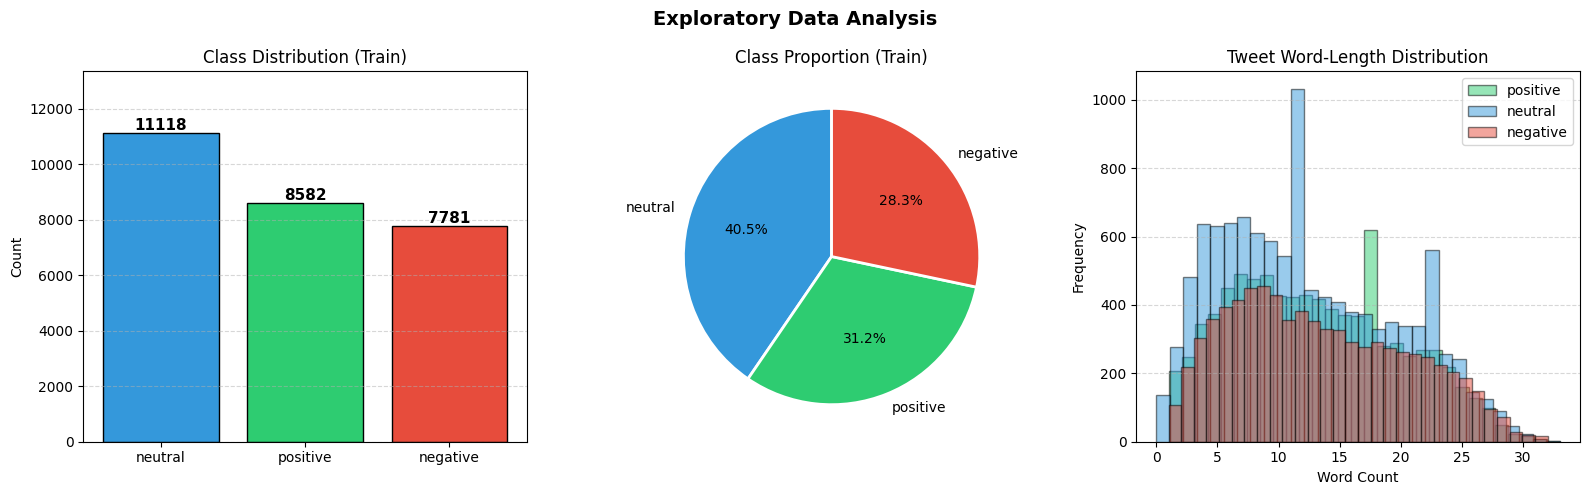


Text length stats (words):
count    27481.00
mean        12.90
std          6.93
min          0.00
25%          7.00
50%         12.00
75%         18.00
max         33.00
Name: text_len, dtype: float64


In [ ]:
# ── 3a. Null check ────────────────────────────────────────────────────────────
print('=== Missing Values ===')
print(train_df.isnull().sum())

# ── 3b. Class distribution ────────────────────────────────────────────────────
label_counts = train_df['sentiment'].value_counts()
print(f'\nClass distribution (train):\n{label_counts}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Exploratory Data Analysis', fontsize=14, fontweight='bold')

# Bar chart
colors = {'positive': '#2ecc71', 'neutral': '#3498db', 'negative': '#e74c3c'}
bars = axes[0].bar(label_counts.index,
                   label_counts.values,
                   color=[colors.get(c, 'grey') for c in label_counts.index],
                   edgecolor='k')
axes[0].bar_label(bars, fontsize=11, fontweight='bold')
axes[0].set_title('Class Distribution (Train)', fontsize=12)
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, label_counts.max() * 1.2)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Pie chart
axes[1].pie(label_counts.values,
            labels=label_counts.index,
            colors=[colors.get(c) for c in label_counts.index],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion (Train)', fontsize=12)

# Text length distribution
train_df['text_len'] = train_df['text'].fillna('').apply(lambda x: len(str(x).split()))
for sentiment, col in colors.items():
    subset = train_df[train_df['sentiment'] == sentiment]['text_len']
    axes[2].hist(subset, bins=30, alpha=0.5, label=sentiment, color=col, edgecolor='k')
axes[2].set_title('Tweet Word-Length Distribution', fontsize=12)
axes[2].set_xlabel('Word Count'); axes[2].set_ylabel('Frequency')
axes[2].legend(); axes[2].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\nText length stats (words):")
print(train_df['text_len'].describe().round(2))

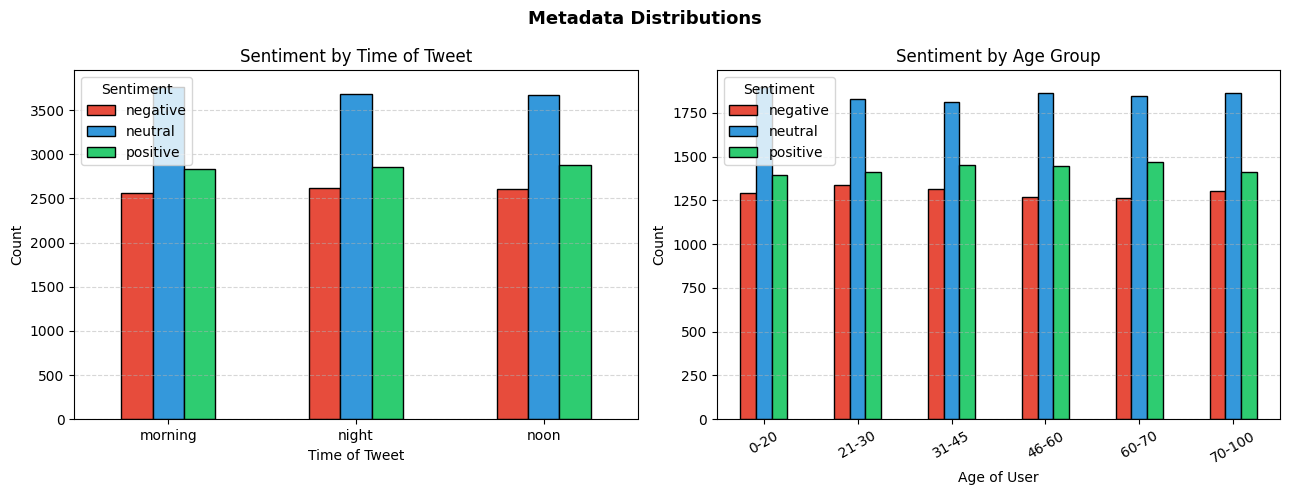

In [ ]:
# ── 3c. Time of Tweet & Age of User distribution ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Metadata Distributions', fontsize=13, fontweight='bold')

# Sentiment by time of tweet
time_sent = train_df.groupby(['Time of Tweet', 'sentiment']).size().unstack(fill_value=0)
time_sent.plot(kind='bar', ax=axes[0],
               color=[colors.get(c, 'grey') for c in time_sent.columns],
               edgecolor='k')
axes[0].set_title('Sentiment by Time of Tweet', fontsize=12)
axes[0].set_xlabel('Time of Tweet'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Sentiment')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Sentiment by age group
age_sent = train_df.groupby(['Age of User', 'sentiment']).size().unstack(fill_value=0)
age_sent.plot(kind='bar', ax=axes[1],
              color=[colors.get(c, 'grey') for c in age_sent.columns],
              edgecolor='k')
axes[1].set_title('Sentiment by Age Group', fontsize=12)
axes[1].set_xlabel('Age of User'); axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Sentiment')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Step 4 — Data Cleaning & Label Encoding

In [ ]:
# ── Text Cleaning ─────────────────────────────────────────────────────────────
def clean_text(text):
    """
    Light cleaning suited for BERTweet:
    - Remove URLs, @mentions, # symbol (keep hashtag word)
    - Normalise whitespace
    BERTweet handles casing and punctuation internally.
    """
    text = str(text)
    text = re.sub(r'http\S+|www\.\S+', '', text)     # URLs
    text = re.sub(r'@\w+', '@user', text)             # mentions → token
    text = re.sub(r'#', '', text)
    text = re.sub(r'&amp;', '&', text)                # HTML entity
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['clean_text'] = train_df['text'].fillna('').apply(clean_text)
test_df['clean_text']  = test_df['text'].fillna('').apply(clean_text)

train_df = train_df.dropna(subset=['sentiment']).reset_index(drop=True)
train_df['sentiment'] = train_df['sentiment'].str.strip().str.lower()
test_df['sentiment']  = test_df['sentiment'].str.strip().str.lower()

train_df['label'] = train_df['sentiment'].map(LABEL_MAP)
test_df['label']  = test_df['sentiment'].map(LABEL_MAP)

train_df = train_df.dropna(subset=['label']).reset_index(drop=True)
test_df  = test_df.dropna(subset=['label']).reset_index(drop=True)
train_df['label'] = train_df['label'].astype(int)
test_df['label']  = test_df['label'].astype(int)

print(f'Clean train size : {len(train_df)}')
print(f'Clean test  size : {len(test_df)}')
print(f'\nLabel distribution:\n{train_df["label"].value_counts().sort_index()}')
print(f'\nSample cleaned text:')
for i in range(3):
    print(f'  [{CLASS_NAMES[train_df.label[i]]}] {train_df.clean_text[i][:80]}')


Clean train size : 27481
Clean test  size : 3534

Label distribution:
label
0     7781
1    11118
2     8582
Name: count, dtype: int64

Sample cleaned text:
  [neutral] I`d have responded, if I were going
  [negative] Sooo SAD I will miss you here in San Diego!!!
  [negative] my boss is bullying me...


In [ ]:
# ── Train / Val Split ─────────────────────────────────────────────────────────
train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    stratify=train_df['label'],
    random_state=SEED
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"Train size: {len(train_df)}")
print(f"Val size  : {len(val_df)}")
print(f"Test size : {len(test_df)}")

Train size: 24732
Val size  : 2749
Test size : 3534


## Step 5 — Tokeniser & Dataset

In [ ]:
# ── Tokenizer ─────────────────────────────────────────────────────────────────
MODEL_NAME = "vinai/bertweet-base"
MAX_LEN    = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Tokenizer loaded: {MODEL_NAME}')
print(f'Vocab size: {tokenizer.vocab_size:,}')

sample_lens = train_df['clean_text'].apply(
    lambda t: len(tokenizer.encode(t, add_special_tokens=True))
)
print(f'Token length — mean: {sample_lens.mean():.1f}  '
      f'p95: {sample_lens.quantile(0.95):.0f}  '
      f'max: {sample_lens.max()}')

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


Tokenizer loaded: vinai/bertweet-base
Vocab size: 64,000
Token length — mean: 19.5  p95: 36  max: 110


In [ ]:
# ── Dataset & DataLoaders ─────────────────────────────────────────────────────
class TweetSentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = list(texts)
        self.labels    = list(labels)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long),
            'text':           self.texts[idx]
        }

BATCH_SIZE  = 32
NUM_WORKERS = 0

train_dataset = TweetSentimentDataset(train_df['clean_text'], train_df['label'], tokenizer, MAX_LEN)
val_dataset   = TweetSentimentDataset(val_df['clean_text'],   val_df['label'],   tokenizer, MAX_LEN)
test_dataset  = TweetSentimentDataset(test_df['clean_text'],  test_df['label'],  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')


Train batches : 773
Val   batches : 86
Test  batches : 111


## Step 6 — Class Imbalance: Compute Class Weights

The dataset is imbalanced (typically ~40% neutral, ~30% positive, ~30% negative). We pass **inverse-frequency class weights** into `CrossEntropyLoss` so the model doesn't bias towards the majority class.

In [ ]:
# ── Class Weights ─────────────────────────────────────────────────────────────
class_counts = np.bincount(train_df['label'], minlength=NUM_LABELS).astype(float)
class_weights = torch.tensor(
    len(train_df) / (NUM_LABELS * class_counts),
    dtype=torch.float32
).to(DEVICE)

print('Class counts  :', {CLASS_NAMES[i]: int(c) for i, c in enumerate(class_counts)})
print('Class weights :', {CLASS_NAMES[i]: f'{w:.4f}' for i, w in enumerate(class_weights.cpu())})

Class counts  : {'negative': 7003, 'neutral': 10006, 'positive': 7723}
Class weights : {'negative': '1.1772', 'neutral': '0.8239', 'positive': '1.0675'}


## Step 7 — Model: RoBERTa-base for Sequence Classification

In [ ]:
# ── Model ─────────────────────────────────────────────────────────────────────
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model       : {MODEL_NAME}')
print(f'Total params: {total_params:,}')
print(f'Trainable   : {trainable_params:,}')

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Model       : vinai/bertweet-base
Total params: 134,902,275
Trainable   : 134,902,275


## Step 8 — Optimiser & Scheduler


In [ ]:
# ── Optimizer with Layer-wise LR Decay ───────────────────────────────────────
NUM_EPOCHS     = 10
LR             = 2e-5
WEIGHT_DECAY   = 0.01
WARMUP_RATIO   = 0.1
GRAD_CLIP      = 1.0
PATIENCE       = 3
CHECKPOINT     = 'best_bertweet_sentiment.pth'   # FIX: name matches actual model
LAYER_LR_DECAY = 0.95
no_decay       = ['bias', 'LayerNorm.weight', 'LayerNorm.bias']

encoder_layers = model.base_model.encoder.layer
num_layers     = len(encoder_layers)

optimizer_params = []

# Classifier head — full LR
optimizer_params += [
    {'params': [p for n, p in model.classifier.named_parameters()
                if p.requires_grad and not any(nd in n for nd in no_decay)],
     'lr': LR, 'weight_decay': WEIGHT_DECAY},
    {'params': [p for n, p in model.classifier.named_parameters()
                if p.requires_grad and any(nd in n for nd in no_decay)],
     'lr': LR, 'weight_decay': 0.0},
]

# Embeddings + Pooler — lowest LR  FIX: pooler now included
for layer_name, layer_module in [
    ('embeddings', model.base_model.embeddings)
    # ('pooler',     model.base_model.pooler),
]:
    decay_lr = LR * (LAYER_LR_DECAY ** num_layers)
    optimizer_params += [
        {'params': [p for n, p in layer_module.named_parameters()
                    if p.requires_grad and not any(nd in n for nd in no_decay)],
         'lr': decay_lr, 'weight_decay': WEIGHT_DECAY},
        {'params': [p for n, p in layer_module.named_parameters()
                    if p.requires_grad and any(nd in n for nd in no_decay)],
         'lr': decay_lr, 'weight_decay': 0.0},
    ]

# Encoder layers — increasing LR from bottom to top
for i, layer in enumerate(encoder_layers):
    layer_lr = LR * (LAYER_LR_DECAY ** (num_layers - i))
    optimizer_params += [
        {'params': [p for n, p in layer.named_parameters()
                    if p.requires_grad and not any(nd in n for nd in no_decay)],
         'lr': layer_lr, 'weight_decay': WEIGHT_DECAY},
        {'params': [p for n, p in layer.named_parameters()
                    if p.requires_grad and any(nd in n for nd in no_decay)],
         'lr': layer_lr, 'weight_decay': 0.0},
    ]

optimizer    = torch.optim.AdamW(optimizer_params)
total_steps  = len(train_loader) * NUM_EPOCHS
warmup_steps = int(WARMUP_RATIO * total_steps)
scheduler    = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)
criterion = nn.CrossEntropyLoss(weight=class_weights)
scaler    = GradScaler()

print(f'Total training steps : {total_steps}')
print(f'Warmup steps         : {warmup_steps}')


Total training steps : 7730
Warmup steps         : 773


## Step 9 — Training & Validation Utilities

In [ ]:
# ── Training & Evaluation Utilities ──────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, scheduler, criterion, scaler, grad_clip):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for batch in loader:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        lbls = batch['label'].to(DEVICE)

        optimizer.zero_grad()
        with autocast():
            logits = model(input_ids=ids, attention_mask=mask).logits
            loss   = criterion(logits, lbls)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item() * lbls.size(0)
        correct    += (logits.argmax(1) == lbls).sum().item()
        total      += lbls.size(0)

    return total_loss / total, 100 * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_labels, all_preds, all_probs, all_texts = [], [], [], []

    for batch in loader:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        lbls = batch['label'].to(DEVICE)

        logits = model(input_ids=ids, attention_mask=mask).logits
        loss   = criterion(logits, lbls)

        probs = torch.softmax(logits, dim=1).cpu()
        preds = probs.argmax(1)

        total_loss += loss.item() * lbls.size(0)
        correct    += (preds == lbls.cpu()).sum().item()
        total      += lbls.size(0)

        all_labels.extend(lbls.cpu().numpy())
        all_preds.extend(preds.numpy())
        all_probs.extend(probs.numpy())

        if 'text' in batch:
            all_texts.extend(batch['text'])

    return (total_loss / total,
            100 * correct / total,
            np.array(all_labels),
            np.array(all_preds),
            np.array(all_probs),
            all_texts)


def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    ax1.plot(epochs, history['train_loss'], 'b-o', ms=5, label='Train')
    ax1.plot(epochs, history['val_loss'],   'r-s', ms=5, label='Validation')
    ax1.set_title('Loss per Epoch', fontsize=12)
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(True, linestyle='--', alpha=0.6)

    ax2.plot(epochs, history['train_acc'], 'b-o', ms=5, label='Train')
    ax2.plot(epochs, history['val_acc'],   'r-s', ms=5, label='Validation')
    ax2.set_title('Accuracy per Epoch', fontsize=12)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
    ax2.legend(); ax2.grid(True, linestyle='--', alpha=0.6)

    # FIX: title now says BERTweet, not RoBERTa-base
    plt.suptitle('BERTweet Fine-Tuning — Training History', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

print('Utilities ready')


Utilities ready


## Step 10 — Fine-Tuning Loop (with Early Stopping)

Epoch 1/10  |  Train Loss: 0.7705  Acc: 62.18%  |  Val Loss: 0.5138  Acc: 78.97%
  New best model saved (val loss: 0.5138, val acc: 78.97%)
Epoch 2/10  |  Train Loss: 0.4733  Acc: 80.62%  |  Val Loss: 0.4678  Acc: 80.14%
  New best model saved (val loss: 0.4678, val acc: 80.14%)
Epoch 3/10  |  Train Loss: 0.3855  Acc: 84.71%  |  Val Loss: 0.5167  Acc: 78.90%
  No improvement (1/3)
Epoch 4/10  |  Train Loss: 0.3058  Acc: 88.59%  |  Val Loss: 0.5464  Acc: 79.70%
  No improvement (2/3)
Epoch 5/10  |  Train Loss: 0.2356  Acc: 91.81%  |  Val Loss: 0.6129  Acc: 79.67%
  No improvement (3/3)
Early stopping triggered.

Best model loaded — Val Loss: 0.4678, Val Acc: 80.14%


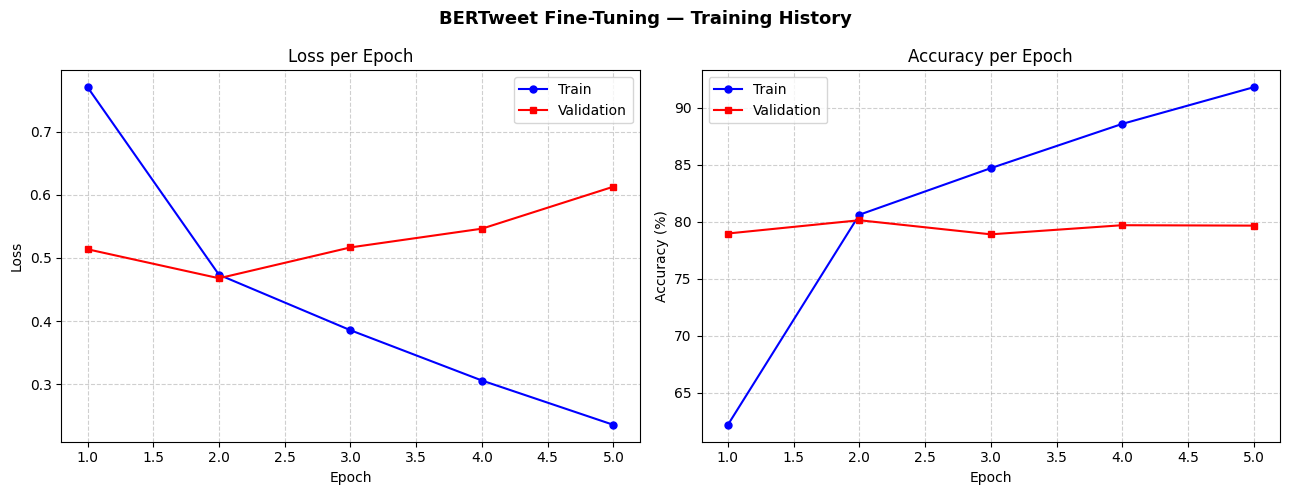

In [ ]:
# ── Training Loop ─────────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

best_val_loss  = float('inf')
best_val_acc   = 0.0
patience_count = 0

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(
        model, train_loader, optimizer, scheduler, criterion, scaler, GRAD_CLIP
    )
    va_loss, va_acc, _, _, _, _ = evaluate(model, val_loader, criterion)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)

    print(f'Epoch {epoch}/{NUM_EPOCHS}  |  '
          f'Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.2f}%  |  '
          f'Val Loss: {va_loss:.4f}  Acc: {va_acc:.2f}%')

    if va_loss < best_val_loss:
        best_val_loss  = va_loss
        best_val_acc   = va_acc
        patience_count = 0
        torch.save(model.state_dict(), CHECKPOINT)
        print(f'  New best model saved (val loss: {best_val_loss:.4f}, val acc: {best_val_acc:.2f}%)')
    else:
        patience_count += 1
        print(f'  No improvement ({patience_count}/{PATIENCE})')
        if patience_count >= PATIENCE:
            print('Early stopping triggered.')
            break

model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE, weights_only=True))
print(f'\nBest model loaded — Val Loss: {best_val_loss:.4f}, Val Acc: {best_val_acc:.2f}%')

plot_history(history)

## Step 11 — Comprehensive Evaluation on Test Set

In [ ]:
# ── Test Evaluation ───────────────────────────────────────────────────────────
_, test_acc, y_true, y_pred, y_prob, test_texts_list = evaluate(
    model, test_loader, criterion
)

report = classification_report(
    y_true, y_pred, target_names=CLASS_NAMES, digits=4, output_dict=True
)
print('=' * 60)
print('CLASSIFICATION REPORT — Test Set')
print('=' * 60)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))
print(f'Overall Test Accuracy : {test_acc:.2f}%')
print(f'Macro F1              : {report["macro avg"]["f1-score"]:.4f}')
# FIX: also report weighted F1 (more informative for imbalanced data)
print(f'Weighted F1           : {report["weighted avg"]["f1-score"]:.4f}')


CLASSIFICATION REPORT — Test Set
              precision    recall  f1-score   support

    negative     0.7533    0.8631    0.8045      1001
     neutral     0.8186    0.6972    0.7530      1430
    positive     0.8323    0.8821    0.8565      1103

    accuracy                         0.8019      3534
   macro avg     0.8014    0.8142    0.8047      3534
weighted avg     0.8044    0.8019    0.7999      3534

Overall Test Accuracy : 80.19%
Macro F1              : 0.8047
Weighted F1           : 0.7999


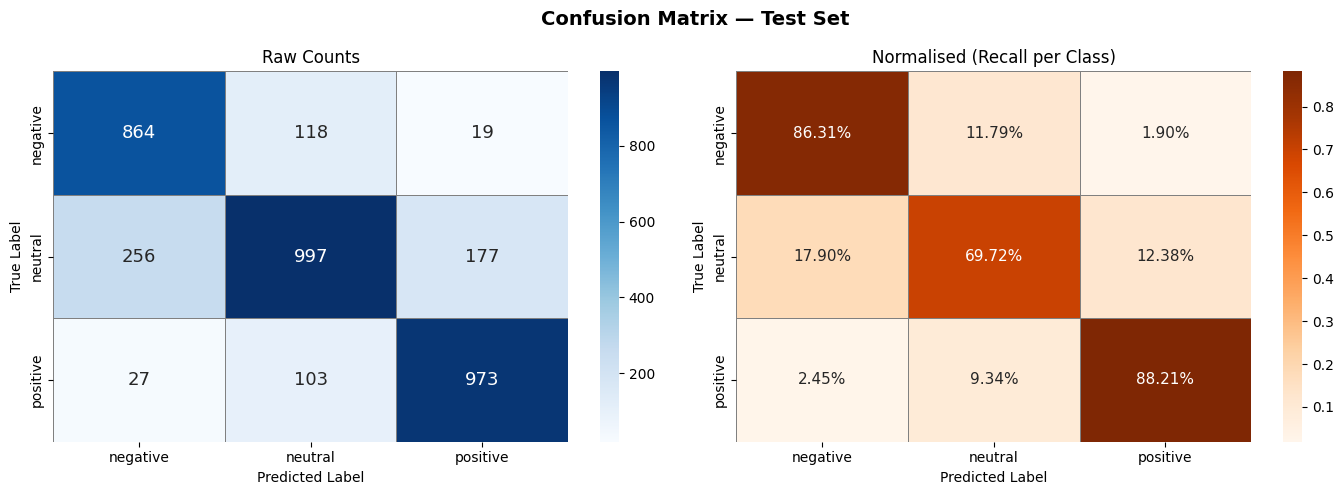

In [ ]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix — Test Set', fontsize=14, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], linewidths=0.5, linecolor='gray',
            annot_kws={'size': 13})
axes[0].set_title('Raw Counts', fontsize=12)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Oranges',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], linewidths=0.5, linecolor='gray',
            annot_kws={'size': 11})
axes[1].set_title('Normalised (Recall per Class)', fontsize=12)
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

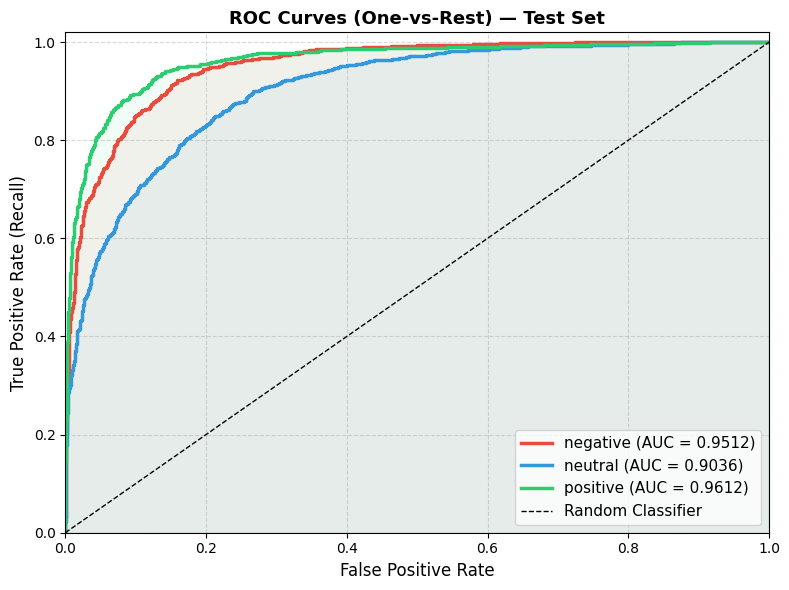


AUC Scores per class:
  negative: 0.9512
  neutral : 0.9036
  positive: 0.9612


In [ ]:
# ── ROC Curves ───────────────────────────────────────────────────────────────
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

fig, ax = plt.subplots(figsize=(8, 6))
auc_scores = {}

for i, (cls, col) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    if len(np.unique(y_true_bin[:, i])) < 2:
        continue
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc     = auc(fpr, tpr)
    auc_scores[cls] = roc_auc
    ax.plot(fpr, tpr, color=col, lw=2.5, label=f'{cls} (AUC = {roc_auc:.4f})')
    ax.fill_between(fpr, tpr, alpha=0.06, color=col)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves (One-vs-Rest) — Test Set', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\nAUC Scores per class:")
for cls, score in auc_scores.items():
    print(f"  {cls:<8}: {score:.4f}")


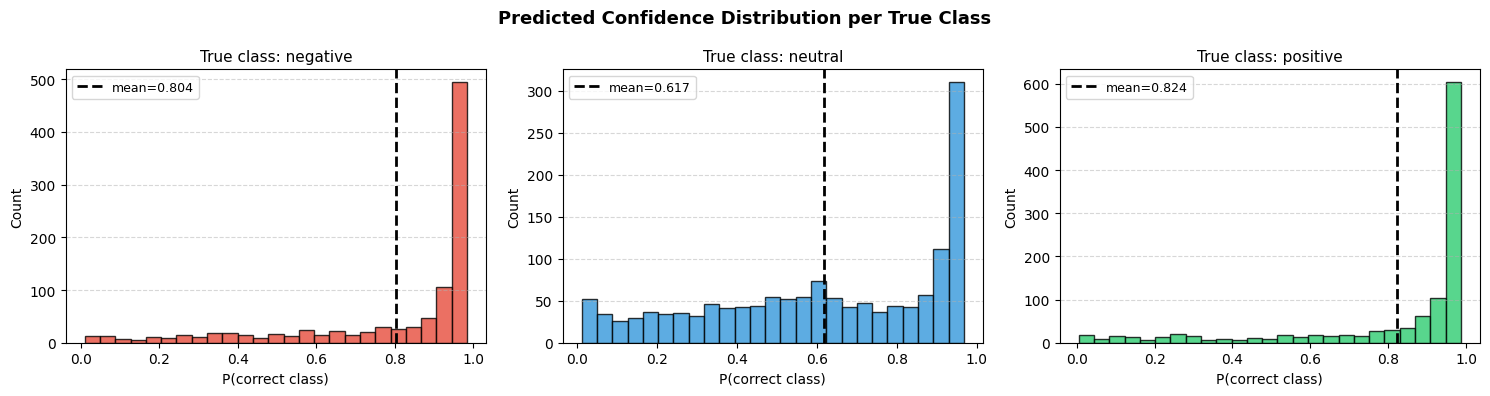

In [ ]:
# ── Confidence Distributions ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Predicted Confidence Distribution per True Class', fontsize=13, fontweight='bold')

for i, (cls, col) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    idx = np.where(y_true == i)[0]
    if len(idx) == 0:
        axes[i].set_title(f'True class: {cls} (no samples)', fontsize=11)
        axes[i].axis('off')
        continue

    conf = y_prob[idx, i]
    axes[i].hist(conf, bins=25, color=col, edgecolor='k', alpha=0.8)
    mean_conf = conf.mean()
    axes[i].axvline(mean_conf, color='black', linewidth=2, linestyle='--',
                    label=f'mean={mean_conf:.3f}')
    axes[i].set_title(f'True class: {cls}', fontsize=11)
    axes[i].set_xlabel('P(correct class)')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=9)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Step 12 — Misclassified Samples Analysis

In [ ]:
# ── Misclassification Analysis ────────────────────────────────────────────────
errors = np.where(y_pred != y_true)[0]

print(f'Misclassified : {len(errors)} / {len(y_true)}  '
      f'({100*len(errors)/len(y_true):.1f}% error rate)')

# FIX: using REV_LABEL_MAP instead of CLASS_NAMES[] indexing
err_true = Counter(REV_LABEL_MAP[y_true[i]] for i in errors)
err_pred = Counter(REV_LABEL_MAP[y_pred[i]] for i in errors)

print(f'\nErrors by true class : {dict(err_true)}')
print(f'Errors by pred class : {dict(err_pred)}')
print('\n--- Sample Misclassifications ---')

for i in errors[:10]:
    conf = y_prob[i, y_pred[i]]
    print(f'  True: {REV_LABEL_MAP[y_true[i]]:<9}  '
          f'Pred: {REV_LABEL_MAP[y_pred[i]]:<9}  '
          f'Conf: {conf:.3f}')
    print(f'  Text: "{test_texts_list[i][:100]}"\n')

Misclassified : 700 / 3534  (19.8% error rate)

Errors by true class : {'neutral': 433, 'positive': 130, 'negative': 137}
Errors by pred class : {'negative': 283, 'neutral': 221, 'positive': 196}

--- Sample Misclassifications ---
  True: neutral    Pred: negative   Conf: 0.804
  Text: ".. and you`re on twitter! Did the tavern bore you that much?"

  True: neutral    Pred: negative   Conf: 0.685
  Text: "I`m going into a spiritual stagnentation, its exploding my ego!. I now realise, i`m not all that gre"

  True: neutral    Pred: negative   Conf: 0.690
  Text: "hey peoples, dont you just hate being grounded haha, im just sat eating an apple and watching death "

  True: neutral    Pred: negative   Conf: 0.586
  Text: "Huh, another ScarePoint coding Sunday"

  True: positive   Pred: neutral    Conf: 0.670
  Text: "look who I found just for you --->"

  True: neutral    Pred: negative   Conf: 0.541
  Text: "There is a faux gothy chick looking at me, sorry I am not going to camden and I l

## Step 13 — Final Summary

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc  = accuracy_score(y_true, y_pred) * 100
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0) * 100
rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0) * 100
f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0) * 100
mac_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0) * 100

auc_scores = {}
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

for i, cls in enumerate(CLASS_NAMES):
    if len(np.unique(y_true_bin[:, i])) < 2:
        auc_scores[cls] = float('nan')   # handle missing class
        continue

    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    auc_scores[cls] = auc(fpr, tpr)

print('\n' + '=' * 60)
print('FINAL RESULTS SUMMARY')
print('=' * 60)

print(f'  Model              : bertweet-base (HuggingFace Transformers)')
print(f'  Fine-tuning epochs : {len(history["train_loss"])} (early stopping patience={PATIENCE})')
print(f'  Max token length   : {MAX_LEN}')
print(f'  Batch size         : {BATCH_SIZE}')
print(f'  Learning rate      : {LR} (layer-wise decay={LAYER_LR_DECAY})')
print(f'  Class weighting    : Yes (inverse-frequency)')
print()

print(f'  Test Accuracy      : {acc:.2f}%')
print(f'  Weighted Precision : {prec:.2f}%')
print(f'  Weighted Recall    : {rec:.2f}%')
print(f'  Weighted F1-Score  : {f1:.2f}%')
print(f'  Macro    F1-Score  : {mac_f1:.2f}%')

print(f'  AUC-ROC  (neg)     : {auc_scores["negative"]:.4f}')
print(f'  AUC-ROC  (neu)     : {auc_scores["neutral"]:.4f}')
print(f'  AUC-ROC  (pos)     : {auc_scores["positive"]:.4f}')

print('=' * 60)

print('\nFull Classification Report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))


FINAL RESULTS SUMMARY
  Model              : bertweet-base (HuggingFace Transformers)
  Fine-tuning epochs : 5 (early stopping patience=3)
  Max token length   : 128
  Batch size         : 32
  Learning rate      : 2e-05 (layer-wise decay=0.95)
  Class weighting    : Yes (inverse-frequency)

  Test Accuracy      : 80.19%
  Weighted Precision : 80.44%
  Weighted Recall    : 80.19%
  Weighted F1-Score  : 79.99%
  Macro    F1-Score  : 80.47%
  AUC-ROC  (neg)     : 0.9512
  AUC-ROC  (neu)     : 0.9036
  AUC-ROC  (pos)     : 0.9612

Full Classification Report:
              precision    recall  f1-score   support

    negative     0.7533    0.8631    0.8045      1001
     neutral     0.8186    0.6972    0.7530      1430
    positive     0.8323    0.8821    0.8565      1103

    accuracy                         0.8019      3534
   macro avg     0.8014    0.8142    0.8047      3534
weighted avg     0.8044    0.8019    0.7999      3534

